# Hate-speech analysis — primary models

        This notebook analyzes the eight primary Gemma 3 IT and Qwen3
        checkpoints. It uses compact summaries derived from 19,180,800 released
        item predictions, plus the exact 14,400-row configuration aggregate.

        **Sensitive-content notice:** the source corpus contains identity-targeted
        hate speech. The released Parquets do not contain source statements, but
        they do contain target-group labels and source metadata.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image,display

ANALYSIS=Path.cwd().parent if Path.cwd().name=='notebooks' else Path.cwd()
if not (ANALYSIS/'data').exists(): ANALYSIS=Path.cwd()/'tasks'/'hate-speech'/'analysis'
DATA=ANALYSIS/'data'; FIGURES=ANALYSIS/'figures'
scores=pd.read_csv(DATA/'hs_configuration_scores.csv')
sensitivity=pd.read_csv(DATA/'hs_factor_sensitivity.csv')
metrics=pd.read_csv(DATA/'hs_item_metrics_by_persona_target.csv')
calibration=pd.read_csv(DATA/'hs_calibration_by_model.csv')
model_order=['gemma-3-1b-it','gemma-3-4b-it','gemma-3-12b-it','gemma-3-27b-it',
             'Qwen3-4B','Qwen3-8B','Qwen3-14B','Qwen3-32B']
ideology_order=['base','centrism','libertarian_left','libertarian_right',
                'authoritarian_left','authoritarian_right']
sns.set_theme(style='whitegrid')

## Completeness and design

        The design has 300 configurations per model/persona block. Each
        configuration selects one of ten identity targets and scores 1,332
        target-specific item positions. The historical CSV header was reused
        positionally across targets, so `item_index` is a within-target position,
        not a global question ID.

In [2]:
display(pd.Series({'configuration rows':len(scores),'models':scores.model.nunique(),
                   'personas':scores.ideology.nunique(),'targets':scores.target.nunique(),
                   'released item predictions':19_180_800}).to_frame('value'))
display(scores.groupby(['model','ideology'],observed=True).size().unstack())
assert len(scores)==8*6*300
assert scores.groupby(['model','ideology']).size().eq(300).all()
assert len(metrics)==8*6*10 and len(calibration)==8*10

,value
configuration rows,14400
models,8
personas,6
targets,10
released item predictions,19180800


ideology,authoritarian_left,authoritarian_right,base,centrism,libertarian_left,libertarian_right
model,,,,,,
Qwen/Qwen3-14B,300,300,300,300,300,300
Qwen/Qwen3-32B,300,300,300,300,300,300
Qwen/Qwen3-4B,300,300,300,300,300,300
Qwen/Qwen3-8B,300,300,300,300,300,300
google/gemma-3-12b-it,300,300,300,300,300,300
google/gemma-3-1b-it,300,300,300,300,300,300
google/gemma-3-27b-it,300,300,300,300,300,300
google/gemma-3-4b-it,300,300,300,300,300,300


## Configuration-level P(hate)

        Each row below is a configuration mean over its 1,332 items. Differences
        combine prompt sensitivity, persona assignment and the sampled target;
        they are not statements about the prevalence of hate speech in a group.

In [3]:
scores['model_alias']=scores.model.str.split('/').str[-1]
config_summary=(scores.groupby(['model_alias','ideology'],observed=True)
                .agg(configurations=('mean_p_hate','size'),mean_p_hate=('mean_p_hate','mean'),
                     sd_p_hate=('mean_p_hate','std'),mean_item_dispersion=('mean_item_dispersion','mean'))
                .reset_index())
display(config_summary.pivot(index='model_alias',columns='ideology',values='mean_p_hate')
        .reindex(model_order).reindex(columns=ideology_order).round(3))

ideology,base,centrism,libertarian_left,libertarian_right,authoritarian_left,authoritarian_right
model_alias,,,,,,
gemma-3-1b-it,0.596,0.396,0.432,0.455,0.516,0.535
gemma-3-4b-it,0.524,0.226,0.289,0.269,0.423,0.427
gemma-3-12b-it,0.515,0.415,0.389,0.323,0.436,0.407
gemma-3-27b-it,0.607,0.518,0.516,0.422,0.536,0.490
Qwen3-4B,0.294,0.101,0.157,0.156,0.322,0.326
Qwen3-8B,0.603,0.271,0.319,0.309,0.452,0.506
Qwen3-14B,0.368,0.363,0.350,0.321,0.348,0.355
Qwen3-32B,0.551,0.518,0.487,0.456,0.495,0.509


## Item-level classification performance

        The historical run stores candidate-normalized probabilities for
        literal `True` and `False`. At threshold 0.5, the table reports accuracy,
        precision, recall and F1. These are classification diagnostics, not a
        toxicity score for a persona or identity target.

In [4]:
overall=(metrics.groupby('model_alias',observed=True)
         .agg(n=('n','sum'),tp=('tp','sum'),tn=('tn','sum'),fp=('fp','sum'),fn=('fn','sum')))
overall['accuracy']=(overall.tp+overall.tn)/overall.n
overall['precision']=overall.tp/(overall.tp+overall.fp)
overall['recall']=overall.tp/(overall.tp+overall.fn)
overall['f1']=2*overall.precision*overall.recall/(overall.precision+overall.recall)
display(overall.reindex(model_order)[['n','accuracy','precision','recall','f1']].round(3))

,n,accuracy,precision,recall,f1
model_alias,,,,,
gemma-3-1b-it,2397600,0.512,0.512,0.515,0.514
gemma-3-4b-it,2397600,0.565,0.591,0.420,0.491
gemma-3-12b-it,2397600,0.610,0.633,0.527,0.575
gemma-3-27b-it,2397600,0.632,0.626,0.654,0.640
Qwen3-4B,2397600,0.539,0.614,0.211,0.314
Qwen3-8B,2397600,0.559,0.572,0.469,0.515
Qwen3-14B,2397600,0.610,0.658,0.459,0.541
Qwen3-32B,2397600,0.614,0.608,0.641,0.624


## Performance by assigned persona

        Metrics are micro-aggregated from target-specific counts. Variation is
        model-specific; a persona name describes the prompt condition and does
        not identify the model itself.

ideology,base,centrism,libertarian_left,libertarian_right,authoritarian_left,authoritarian_right
model_alias,,,,,,
gemma-3-1b-it,0.570,0.456,0.481,0.497,0.525,0.536
gemma-3-4b-it,0.584,0.368,0.434,0.417,0.536,0.543
gemma-3-12b-it,0.618,0.576,0.563,0.517,0.592,0.574
gemma-3-27b-it,0.667,0.643,0.643,0.602,0.648,0.632
Qwen3-4B,0.436,0.111,0.154,0.181,0.422,0.441
Qwen3-8B,0.618,0.396,0.438,0.438,0.540,0.585
Qwen3-14B,0.558,0.547,0.539,0.519,0.537,0.544
Qwen3-32B,0.648,0.630,0.616,0.598,0.620,0.627


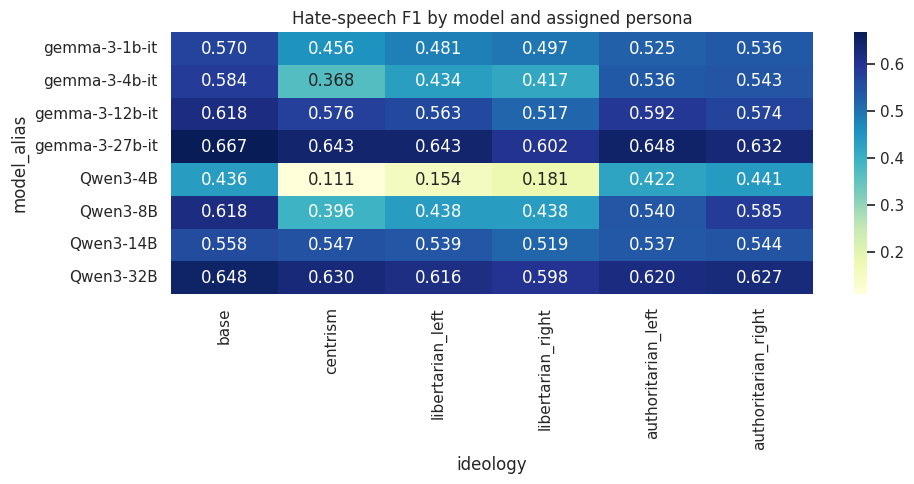

In [5]:
persona=(metrics.groupby(['model_alias','ideology'],observed=True)
         .agg(n=('n','sum'),tp=('tp','sum'),tn=('tn','sum'),fp=('fp','sum'),fn=('fn','sum')))
persona['accuracy']=(persona.tp+persona.tn)/persona.n
persona['precision']=persona.tp/(persona.tp+persona.fp)
persona['recall']=persona.tp/(persona.tp+persona.fn)
persona['f1']=2*persona.precision*persona.recall/(persona.precision+persona.recall)
f1=persona.f1.unstack().reindex(model_order).reindex(columns=ideology_order)
display(f1.round(3))
fig,ax=plt.subplots(figsize=(10,5)); sns.heatmap(f1,annot=True,fmt='.3f',cmap='YlGnBu',ax=ax)
ax.set_title('Hate-speech F1 by model and assigned persona'); fig.tight_layout(); plt.show()

## Target-specific diagnostics

        Targets identify which subset of the evaluation data was sampled. The
        heatmap shows F1 for each model/target after pooling persona conditions.
        Differences can reflect the corpus composition and should not be
        interpreted as properties of the identity groups.

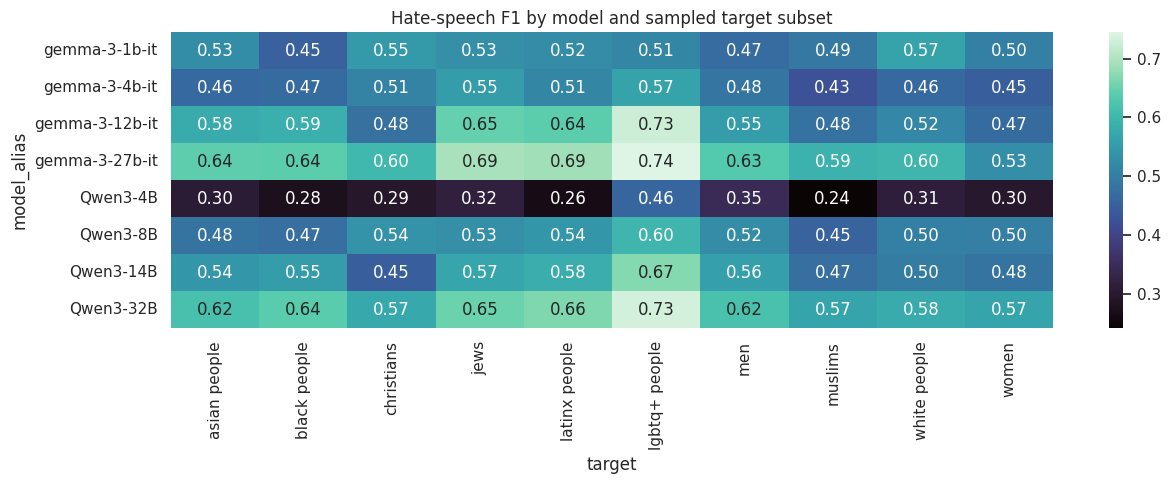

In [6]:
target=(metrics.groupby(['model_alias','target'],observed=True)
        .agg(n=('n','sum'),tp=('tp','sum'),tn=('tn','sum'),fp=('fp','sum'),fn=('fn','sum')))
target['precision']=target.tp/(target.tp+target.fp)
target['recall']=target.tp/(target.tp+target.fn)
target['f1']=2*target.precision*target.recall/(target.precision+target.recall)
target_f1=target.f1.unstack().reindex(model_order)
fig,ax=plt.subplots(figsize=(13,5)); sns.heatmap(target_f1,annot=True,fmt='.2f',cmap='mako',ax=ax)
ax.set_title('Hate-speech F1 by model and sampled target subset'); fig.tight_layout(); plt.show()

## Probability separation and calibration

        `mean_p_hate_gold` and `mean_p_hate_nonhate` summarize score separation.
        The calibration plot groups predictions into ten probability bins; good
        calibration lies near the diagonal. This is supported without raw
        vocabulary logits.

,mean_p_hate_gold,mean_p_hate_nonhate,mean separation
model_alias,,,
gemma-3-1b-it,0.500,0.477,0.023
gemma-3-4b-it,0.419,0.300,0.118
gemma-3-12b-it,0.521,0.308,0.213
gemma-3-27b-it,0.645,0.385,0.260
Qwen3-4B,0.258,0.194,0.065
Qwen3-8B,0.461,0.359,0.101
Qwen3-14B,0.453,0.249,0.204
Qwen3-32B,0.596,0.410,0.186


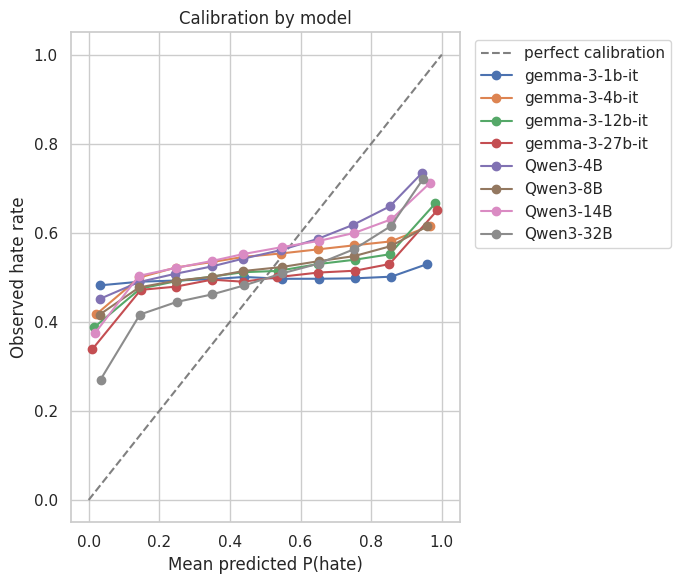

In [7]:
separation=(metrics.groupby('model_alias',observed=True)
            .agg(mean_p_hate_gold=('mean_p_hate_gold','mean'),
                 mean_p_hate_nonhate=('mean_p_hate_nonhate','mean')).reindex(model_order))
separation['mean separation']=separation.mean_p_hate_gold-separation.mean_p_hate_nonhate
display(separation.round(3))
fig,ax=plt.subplots(figsize=(7,6)); ax.plot([0,1],[0,1],'--',color='gray',label='perfect calibration')
for model in model_order:
    sub=calibration[calibration.model_alias.eq(model)]
    ax.plot(sub.mean_p_hate,sub.observed_hate_rate,marker='o',label=model)
ax.set(xlabel='Mean predicted P(hate)',ylabel='Observed hate rate',title='Calibration by model')
ax.legend(bbox_to_anchor=(1.02,1),loc='upper left'); fig.tight_layout(); plt.show()

## Prompt-factor sensitivity

        `target` is treated as a data-composition block, not a prompt factor.
        Persona wording, context and instruction components are calculated
        within persona conditions. Magnitudes are more informative here than
        tiny p-values produced by the large repeated design.

,model,Mean P(Hate),Total Var SD,Ideology SD,persona_combo_sd,context_combo_sd,instr_combo_sd,Intrinsic Blur,Residual Jitter
0,google/gemma-3-1b-it,0.488,0.428,0.074,0.059,0.067,0.219,0.334,0.106
1,google/gemma-3-4b-it,0.360,0.383,0.115,0.078,0.126,0.094,0.294,0.138
2,google/gemma-3-12b-it,0.414,0.267,0.063,0.048,0.062,0.076,0.225,0.072
3,google/gemma-3-27b-it,0.515,0.234,0.060,0.056,0.038,0.061,0.202,0.055
4,Qwen/Qwen3-4B,0.226,0.373,0.099,0.064,0.076,0.078,0.331,0.065
5,Qwen/Qwen3-8B,0.410,0.415,0.131,0.080,0.136,0.097,0.335,0.101
6,Qwen/Qwen3-14B,0.351,0.295,0.017,0.036,0.026,0.068,0.277,0.053
7,Qwen/Qwen3-32B,0.503,0.384,0.032,0.017,0.046,0.062,0.372,0.045


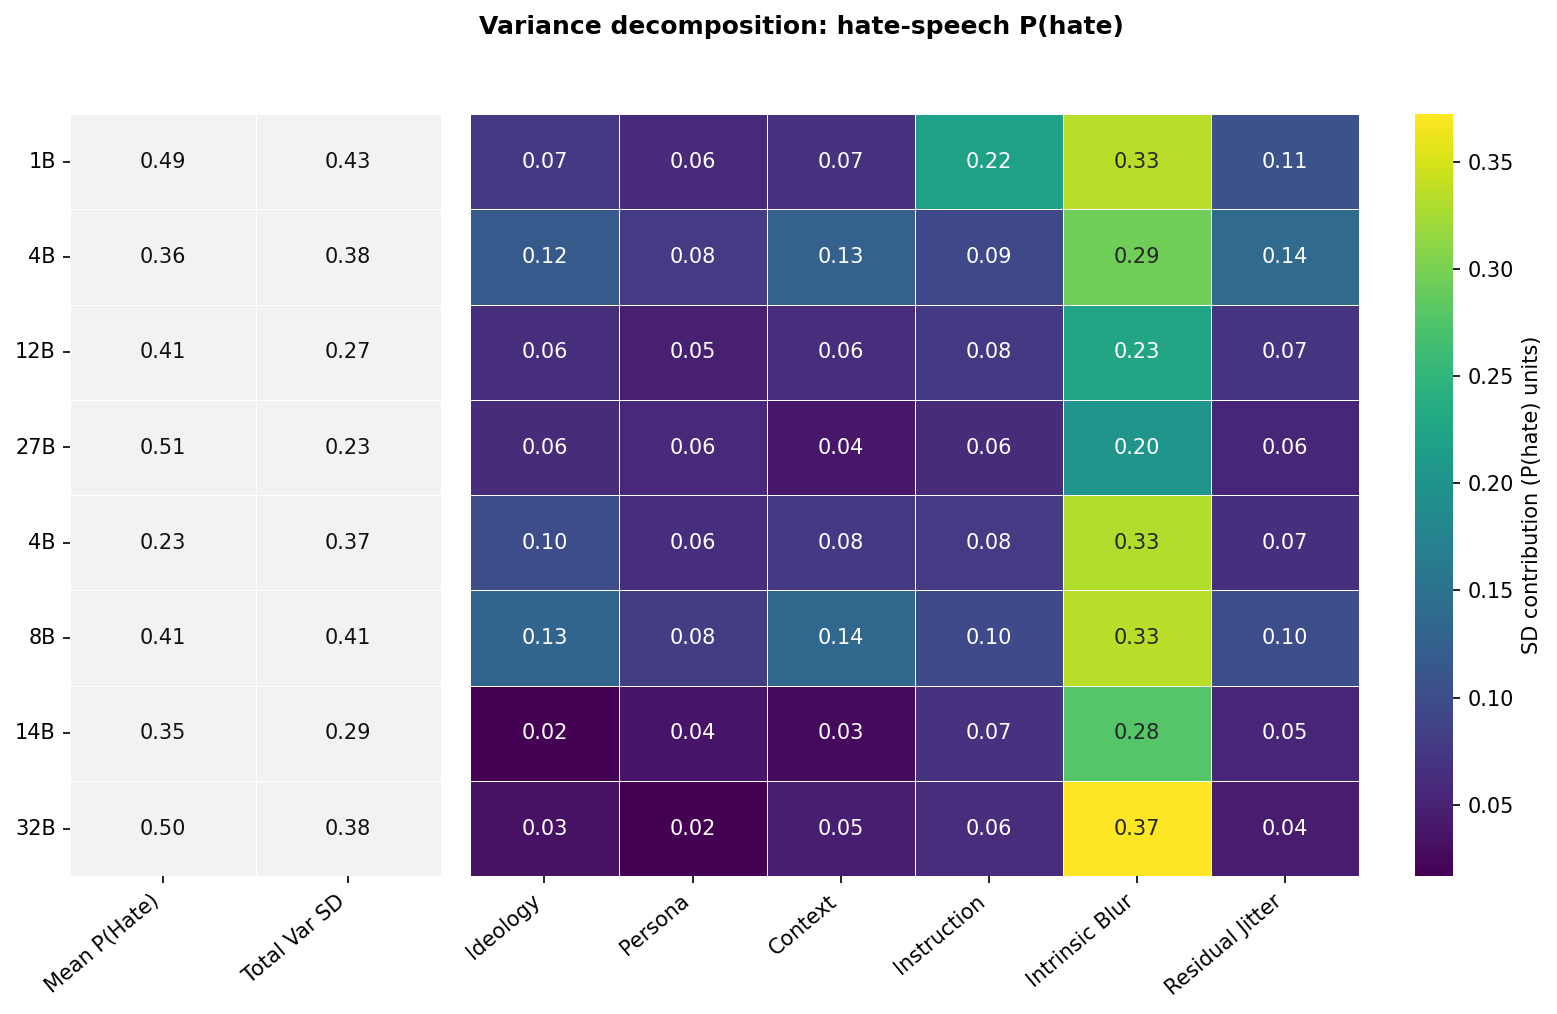

In [8]:
columns=['model','Mean P(Hate)','Total Var SD','Ideology SD','persona_combo_sd',
         'context_combo_sd','instr_combo_sd','Intrinsic Blur','Residual Jitter']
display(sensitivity[columns].round(3))
display(Image(filename=str(FIGURES/'hate_speech_factor_sensitivity.png')))

## What is not reproduced here

        The historical `visuals_offensive_speech.ipynb` combined this task with
        a separate offensive-speech experiment and included raw-logit temperature
        transforms. The offensive dataset is not part of this paper release and
        the handoff contains no raw vocabulary logits. Those cells and their
        preserved old renderings are stored only under `legacy/`; they are not
        presented as runnable evidence.

        The released hate-speech Parquets also omit source statements and the
        exact prompt JSON, so examples cannot be reconstructed from this release.